In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
train_images = "/content/drive/MyDrive/75_24/train/images"
train_labels = "/content/drive/MyDrive/75_24/train/labels"

test_images  = "/content/drive/MyDrive/75_24/test/images"
test_labels  = "/content/drive/MyDrive/75_24/test/labels"


In [ ]:
!nvidia-smi

Wed Jan  7 08:21:56 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   53C    P0             28W /   70W |     710MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
!pip install ultralytics
from ultralytics import YOLO

In [ ]:
import os
import cv2
import torch
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from ultralytics import YOLO
from sklearn.metrics import classification_report, confusion_matrix

# Check GPU availability
print(f"PyTorch Version: {torch.__version__}")
if torch.cuda.is_available():
    print(f"GPU Detected: {torch.cuda.get_device_name(0)}")
    device = 0
else:
    print("WARNING: No GPU detected. Training will be slow on CPU.")
    device = 'cpu'

PyTorch Version: 2.9.0+cu126
GPU Detected: Tesla T4


In [ ]:
import os
from ultralytics import YOLO

# Path to the Ultralytics cache directory for weights (not strictly needed with manual download but kept for context)
weights_cache_dir = os.path.expanduser("~/.cache/ultralytics/weights")
corrupted_model_path = os.path.join(weights_cache_dir, "yolov8s.pt")

# Ensure the cache directory exists to avoid errors later
os.makedirs(weights_cache_dir, exist_ok=True)

# Remove any potentially corrupted files from the cache or local directory
if os.path.exists(corrupted_model_path):
    print(f"Removing corrupted model file from cache: {corrupted_model_path}")
    os.remove(corrupted_model_path)

if os.path.exists("/content/yolov8s.pt"):
    print(f"Removing existing yolov8s.pt from /content/")
    os.remove("/content/yolov8s.pt")

# Manually download the yolov8s.pt model
print("Manually downloading yolov8s.pt...")
!wget -q https://github.com/ultralytics/assets/releases/download/v8.2.0/yolov8s.pt -P /content/
print("Download complete.")

# Initialize the model using the explicitly downloaded file
model = YOLO("/content/yolov8s.pt")
model.train(
    data="/content/drive/MyDrive/75_24/data.yaml",
    epochs=100,
    imgsz=640,
    batch=8,
    freeze=10,
    lr0=0.0003,
    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,
    degrees=10,
    scale=0.5,
    fliplr=0.5,
    mosaic=1.0,
    mixup=0.1,
    name="yolo_augmented"
)


Removing existing yolov8s.pt from /content/
Manually downloading yolov8s.pt...
Download complete.
Ultralytics 8.3.248 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/75_24/data.yaml, degrees=10, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=10, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0003, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=/content/yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=yolo_augmented3, nbs=6

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 3, 4])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7f40f55108f0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04

In [ ]:
results = model.predict("/content/drive/MyDrive/Yolov8/test/images")
results1 = model.predict("/content/drive/MyDrive/Yolov8/valid/images")


image 1/34 /content/drive/MyDrive/Yolov8/test/images/112_jpg.rf.f6d35bd002c5a829eec42f110f04e66f.jpg: 640x608 204 Fruit Treess, 4 Palm_Treess, 43.5ms
image 2/34 /content/drive/MyDrive/Yolov8/test/images/116_jpg.rf.b427fe2157afad15b5b954a838f60b99.jpg: 640x576 159 Fruit Treess, 13 Palm_Treess, 66.2ms
image 3/34 /content/drive/MyDrive/Yolov8/test/images/120_jpg.rf.d562a0964dffc5b7aae7a03bf46f5771.jpg: 640x384 176 Field cropss, 46.4ms
image 4/34 /content/drive/MyDrive/Yolov8/test/images/130_jpg.rf.d180fad514b5bacae6d25240ee674664.jpg: 640x448 1 Field crops, 4 Palm_Treess, 44.2ms
image 5/34 /content/drive/MyDrive/Yolov8/test/images/132_jpg.rf.edaa6f4dc2935a42e7dd78f5a11dc656.jpg: 640x640 1 Fruit Trees, 185 Palm_Treess, 17.1ms
image 6/34 /content/drive/MyDrive/Yolov8/test/images/135_jpg.rf.a57ff4d1ec5162f21ca43810cf7491a1.jpg: 640x448 2 Field cropss, 12.7ms
image 7/34 /content/drive/MyDrive/Yolov8/test/images/150_jpg.rf.69b988db43d2d2fe10025810a70c9e74.jpg: 640x640 1 Field crops, 1 Palm_Tr

In [ ]:
import os
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

test_label_dir = test_labels

y_true = []
y_pred = []

for r in results:
    img_name = os.path.basename(r.path)
    lbl_path = os.path.join(test_label_dir, img_name.replace(".jpg", ".txt"))

    # TRUE LABEL
    if os.path.exists(lbl_path):
        with open(lbl_path, "r") as f:
            lines = f.readlines()
            cls_true = int(lines[0].split()[0]) if len(lines) > 0 else 0
    else:
        cls_true = 0

    # PREDICTED LABEL
    if len(r.boxes.cls) > 0:
        cls_pred = int(r.boxes.cls.cpu().numpy()[0])
    else:
        cls_pred = 0

    y_true.append(cls_true)
    y_pred.append(cls_pred)


In [ ]:
import numpy as np
from sklearn.metrics import classification_report

# Get all unique labels from y_true and y_pred
labels = sorted(list(np.unique(y_true + y_pred)))

# Get class names from the trained model
class_names_dict = model.names

# Create a list of target names corresponding to the unique labels
target_names = [class_names_dict[label] for label in labels]

print(classification_report(y_true, y_pred, labels=labels, target_names=target_names))

              precision    recall  f1-score   support

 Field crops       0.83      0.20      0.32        25
 Fruit Trees       0.67      1.00      0.80         2
 Green House       0.20      1.00      0.33         1
      Others       0.00      0.00      0.00         1
  Palm_Trees       0.27      0.80      0.40         5

    accuracy                           0.35        34
   macro avg       0.39      0.60      0.37        34
weighted avg       0.70      0.35      0.35        34



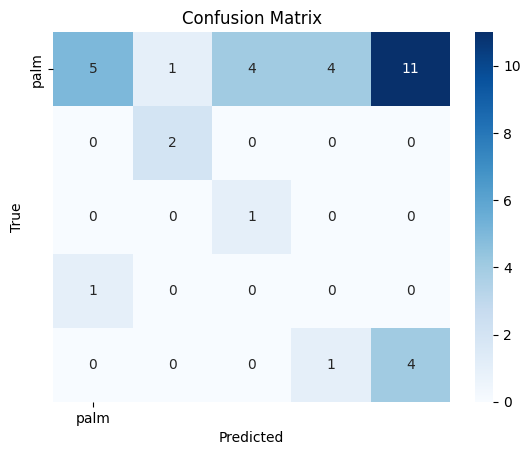

In [ ]:
cm = confusion_matrix(y_true, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["palm"], yticklabels=["palm"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()


              precision    recall  f1-score   support

 Field crops       0.50      0.50      0.50         4
 Green House       0.00      0.00      0.00         2
      Others       1.00      0.83      0.91         6
  Palm_Trees       0.79      0.94      0.86        16

    accuracy                           0.79        28
   macro avg       0.57      0.57      0.57        28
weighted avg       0.74      0.79      0.76        28



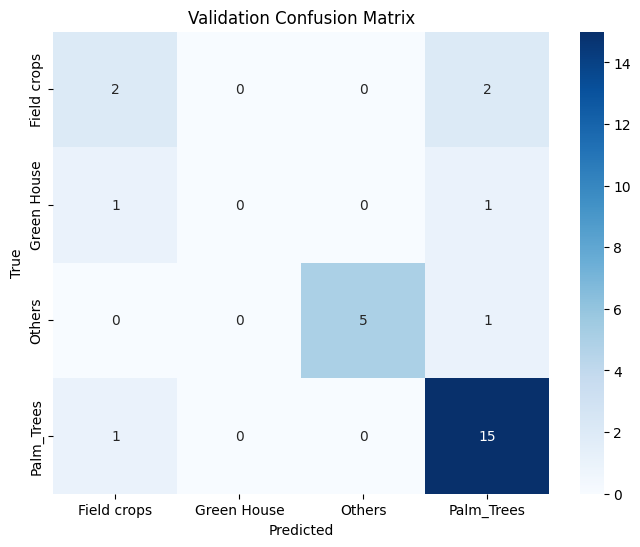

In [ ]:
val_image_dir = "/content/drive/MyDrive/Yolov8/valid/images"
val_label_dir = "/content/drive/MyDrive/Yolov8/valid/labels"

# Class names (EDIT if needed)
# Removed hardcoded class_names to dynamically generate them later.

y_true = []
y_pred = []

# -----------------------------------
# LOOP OVER YOLO PREDICTIONS
# -----------------------------------
for r in results1:
    img_name = os.path.basename(r.path)
    lbl_path = os.path.join(val_label_dir, img_name.replace(".jpg", ".txt"))

    # -----------------------------
    # TRUE LABELS
    # -----------------------------
    true_classes = []
    if os.path.exists(lbl_path):
        with open(lbl_path, "r") as f:
            for line in f:
                true_classes.append(int(line.split()[0]))

    # Skip images with no GT objects
    if len(true_classes) == 0:
        continue

    # -----------------------------
    # PREDICTED LABEL (highest confidence)
    # -----------------------------
    if len(r.boxes.cls) > 0:
        confs = r.boxes.conf.cpu().numpy()
        classes = r.boxes.cls.cpu().numpy()
        cls_pred = int(classes[np.argmax(confs)])
    else:
        # If no predictions, consider it a background/no detection
        # You might want to handle this differently based on your goal
        continue

    # -----------------------------
    # APPEND (image-level dominant class)
    # -----------------------------
    # Assuming the first true class represents the dominant class for simplicity
    y_true.append(true_classes[0])
    y_pred.append(cls_pred)

# Get all unique labels from y_true and y_pred for proper report generation
labels_present = sorted(list(np.unique(y_true + y_pred)))

# Get class names from the trained model's dictionary
class_names_dict = model.names

# Create a list of target names corresponding to the unique labels present
target_names_for_report = [class_names_dict[label] for label in labels_present]

# -----------------------------------
# CLASSIFICATION REPORT
# -----------------------------------
print(classification_report(
    y_true,
    y_pred,
    labels=labels_present, # Specify the actual labels present
    target_names=target_names_for_report,
    zero_division=0
))

# -----------------------------------
# CONFUSION MATRIX
# -----------------------------------
cm = confusion_matrix(y_true, y_pred, labels=labels_present)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=target_names_for_report,
    yticklabels=target_names_for_report
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Validation Confusion Matrix")
plt.show()


In [ ]:
model.export(format="onnx")      # ONNX
model.export(format="torchscript")

Ultralytics 8.3.248 🚀 Python-3.12.12 torch-2.9.0+cu126 CPU (Intel Xeon CPU @ 2.20GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/

PyTorch: starting from '/content/runs/detect/yolo_augmented3/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 9, 8400) (21.5 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxslim>=0.1.71', 'onnxruntime-gpu'] not found, attempting AutoUpdate...
Using Python 3.12.12 environment at: /usr
Resolved 14 packages in 226ms
Prepared 6 packages in 7.60s
Installed 6 packages in 262ms
 + colorama==0.4.6
 + coloredlogs==15.0.1
 + humanfriendly==10.0
 + onnx==1.20.0
 + onnxruntime-gpu==1.23.2
 + onnxslim==0.1.82

requirements: AutoUpdate success ✅ 8.8s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.20.0 opset 22...


/usr/local/lib/python3.12/dist-packages/torch/onnx/_internal/torchscript_exporter/utils.py:1447: OnnxExporterWarning: Exporting to ONNX opset version 22 is not supported. by 'torch.onnx.export()'. The highest opset version supported is 20. To use a newer opset version, consider 'torch.onnx.export(..., dynamo=True)'. 
  warnings.warn(


ONNX: slimming with onnxslim 0.1.82...
ONNX: export success ✅ 10.7s, saved as '/content/runs/detect/yolo_augmented3/weights/best.onnx' (42.7 MB)

Export complete (11.7s)
Results saved to /content/runs/detect/yolo_augmented3/weights
Predict:         yolo predict task=detect model=/content/runs/detect/yolo_augmented3/weights/best.onnx imgsz=640  
Validate:        yolo val task=detect model=/content/runs/detect/yolo_augmented3/weights/best.onnx imgsz=640 data=/content/drive/MyDrive/75_24/data.yaml  
Visualize:       https://netron.app
Ultralytics 8.3.248 🚀 Python-3.12.12 torch-2.9.0+cu126 CPU (Intel Xeon CPU @ 2.20GHz)

PyTorch: starting from '/content/runs/detect/yolo_augmented3/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 9, 8400) (21.5 MB)

TorchScript: starting export with torch 2.9.0+cu126...
TorchScript: export success ✅ 3.5s, saved as '/content/runs/detect/yolo_augmented3/weights/best.torchscript' (42.9 MB)

Export complete (4.5s)
Results saved to

'/content/runs/detect/yolo_augmented3/weights/best.torchscript'